# Lab 4 – Intensity Transformations and Filtering (Spatial Domain)

In [1]:
import os
import cv2
import requests
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure
from skimage.exposure import match_histograms

os.makedirs('images', exist_ok=True)

def get_img(url):
    resp = requests.get(url)
    return cv2.imdecode(np.frombuffer(resp.content, np.uint8), cv2.IMREAD_GRAYSCALE)

## Task#1: Thresholding
Apply thresholding with fixed thresholds (0, 50, 100, 150, 200).

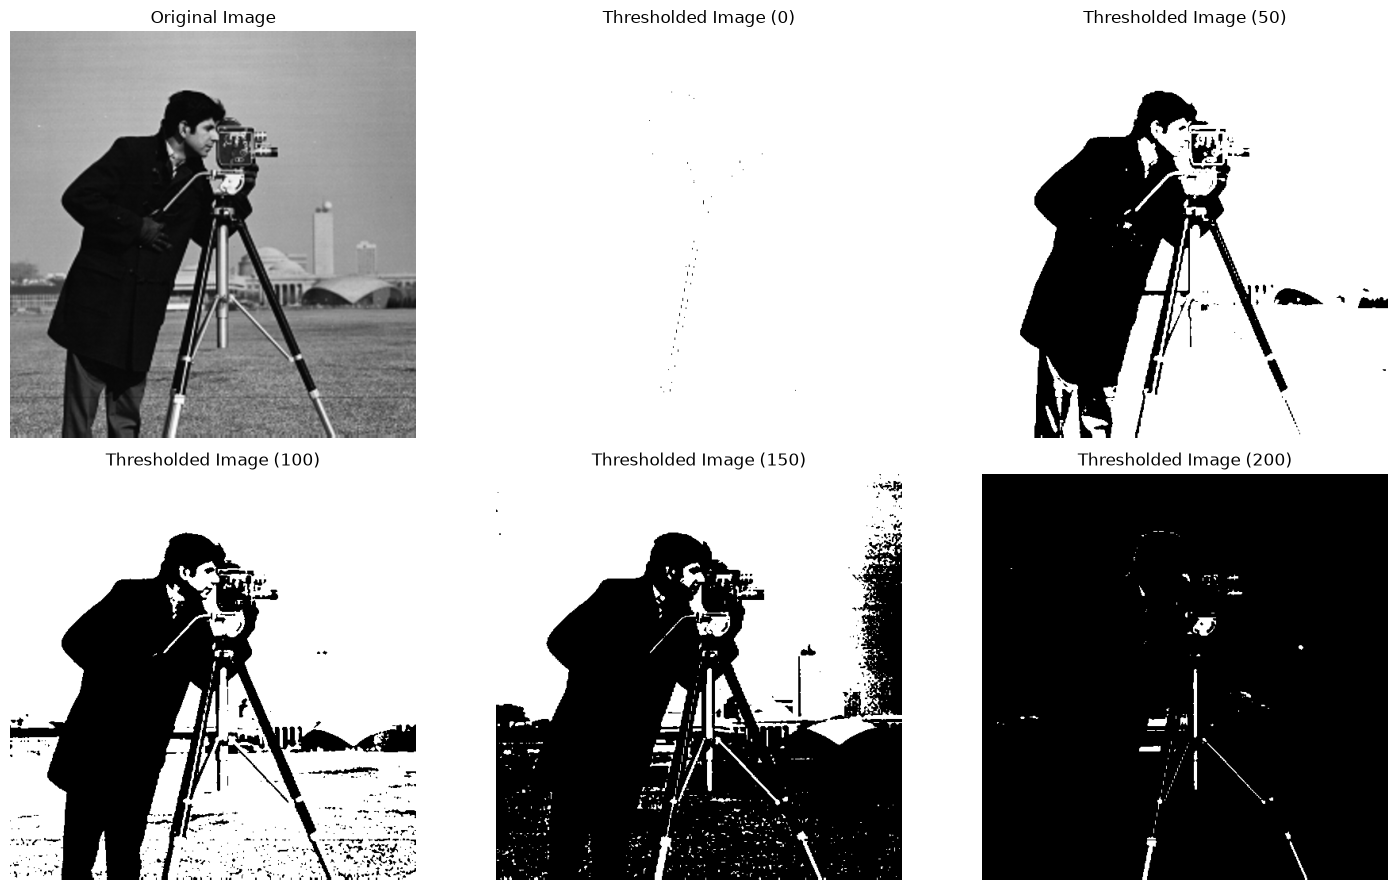

In [2]:
img = get_img("https://raw.githubusercontent.com/ashish-kmr/BTP_inpaint/master/cameraman.tif")
cv2.imwrite('images/cameraman.png', img)

threshold_values = [0, 50, 100, 150, 200]

fig, axs = plt.subplots(2, 3, figsize=(15, 9))
axs.flat[0].imshow(img, cmap='gray'); axs.flat[0].set_title('Original Image')
for ax, t in zip(axs.flat[1:], threshold_values):
    ret, thresh = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
    ax.imshow(thresh, cmap='gray', vmin=0, vmax=255); ax.set_title(f'Thresholded Image ({t})')
[ax.axis('off') for ax in axs.flat]
plt.tight_layout(); plt.show()

## Task#2: Histogram Processing

In [3]:
def show_with_hist(image, title):
    fig = plt.figure(figsize=(10, 7))
    fig.add_subplot(2, 1, 1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.title(title)
    fig.add_subplot(2, 1, 2)
    plt.hist(image.flat, bins=256, range=(0, 255))
    plt.xlabel('gray level values')
    plt.ylabel('Number of pixels')
    plt.show()

In [4]:
img = data.moon()
cv2.imwrite('images/moon.png', img)

# Contrast stretching (2nd - 98th percentiles)
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

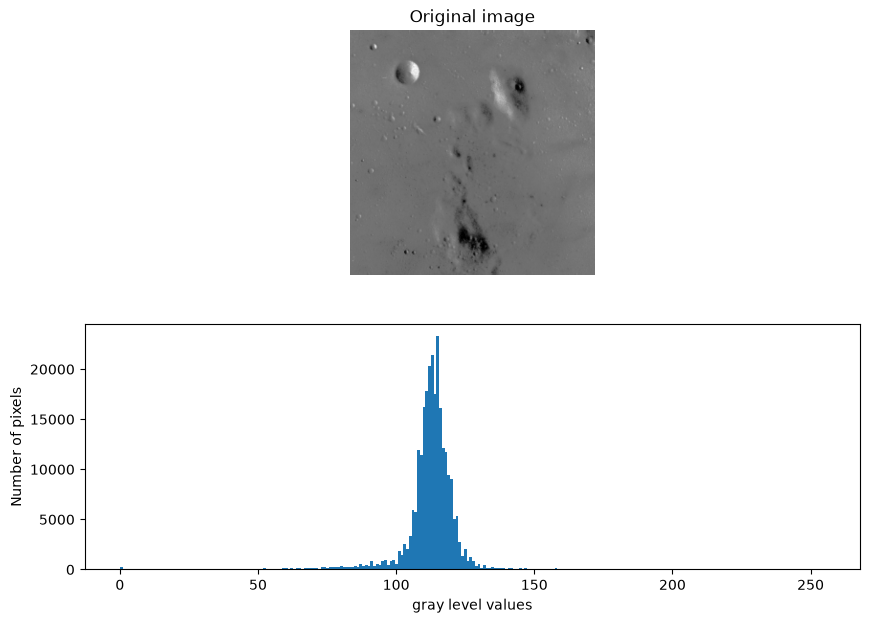

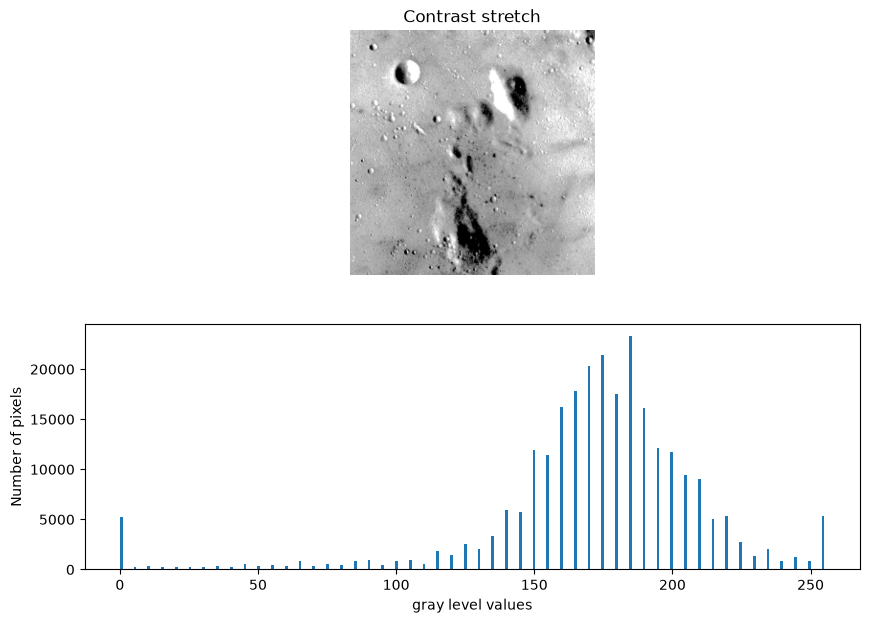

In [5]:
show_with_hist(img, 'Original image')
show_with_hist(img_rescale, 'Contrast stretch')

# Assessment

### Task#1: Rescale the moon image to the 3rd – 80th percentiles and plot the histogram

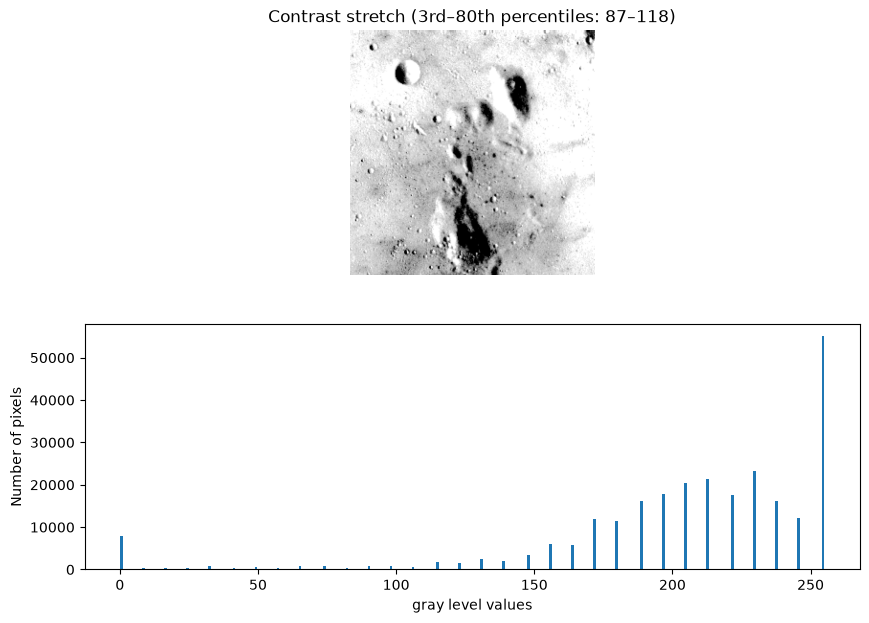

In [6]:
p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))
cv2.imwrite('images/moon_stretch_3_80.png', img_rescale_3_80)
show_with_hist(img_rescale_3_80, f'Contrast stretch (3rd–80th percentiles: {p3:.0f}–{p80:.0f})')

### Task#2: Histogram equalization with `exposure.equalize_hist`

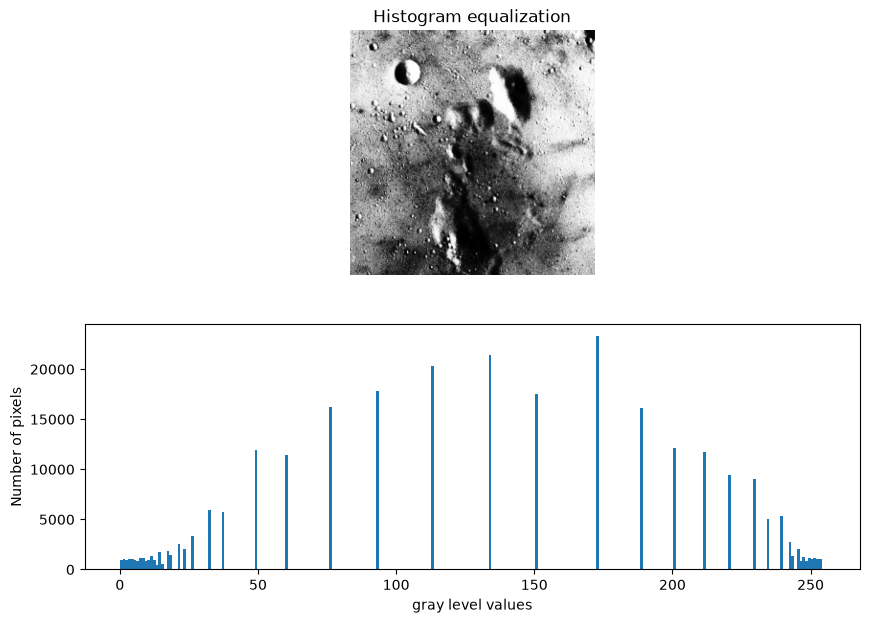

In [7]:
img_eq = exposure.equalize_hist(img)            # float in [0, 1]
img_eq = (img_eq * 255).astype(np.uint8)          # back to 0-255 for the histogram
cv2.imwrite('images/moon_equalized.png', img_eq)
show_with_hist(img_eq, 'Histogram equalization')

### Task#3: Histogram matching – Chelsea image matched to the rocket image (reference)

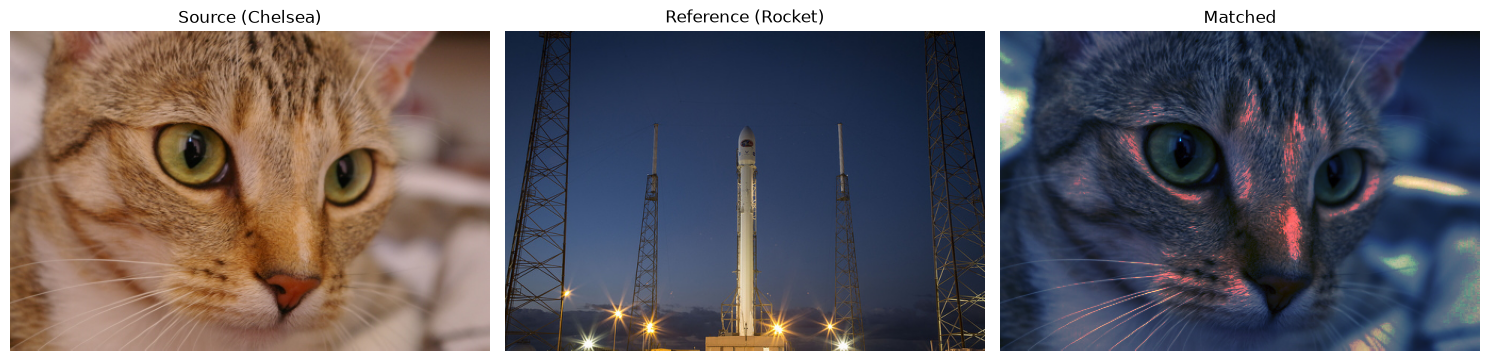

In [8]:
reference = data.rocket()
image = data.chelsea()
matched = match_histograms(image, reference, channel_axis=-1)

cv2.imwrite('images/rocket.png', cv2.cvtColor(reference, cv2.COLOR_RGB2BGR))
cv2.imwrite('images/chelsea.png', cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
cv2.imwrite('images/chelsea_matched.png', cv2.cvtColor(matched.astype(np.uint8), cv2.COLOR_RGB2BGR))

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, im, t in zip(axs, [image, reference, matched], ['Source (Chelsea)', 'Reference (Rocket)', 'Matched']):
    ax.imshow(im.astype(np.uint8)); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

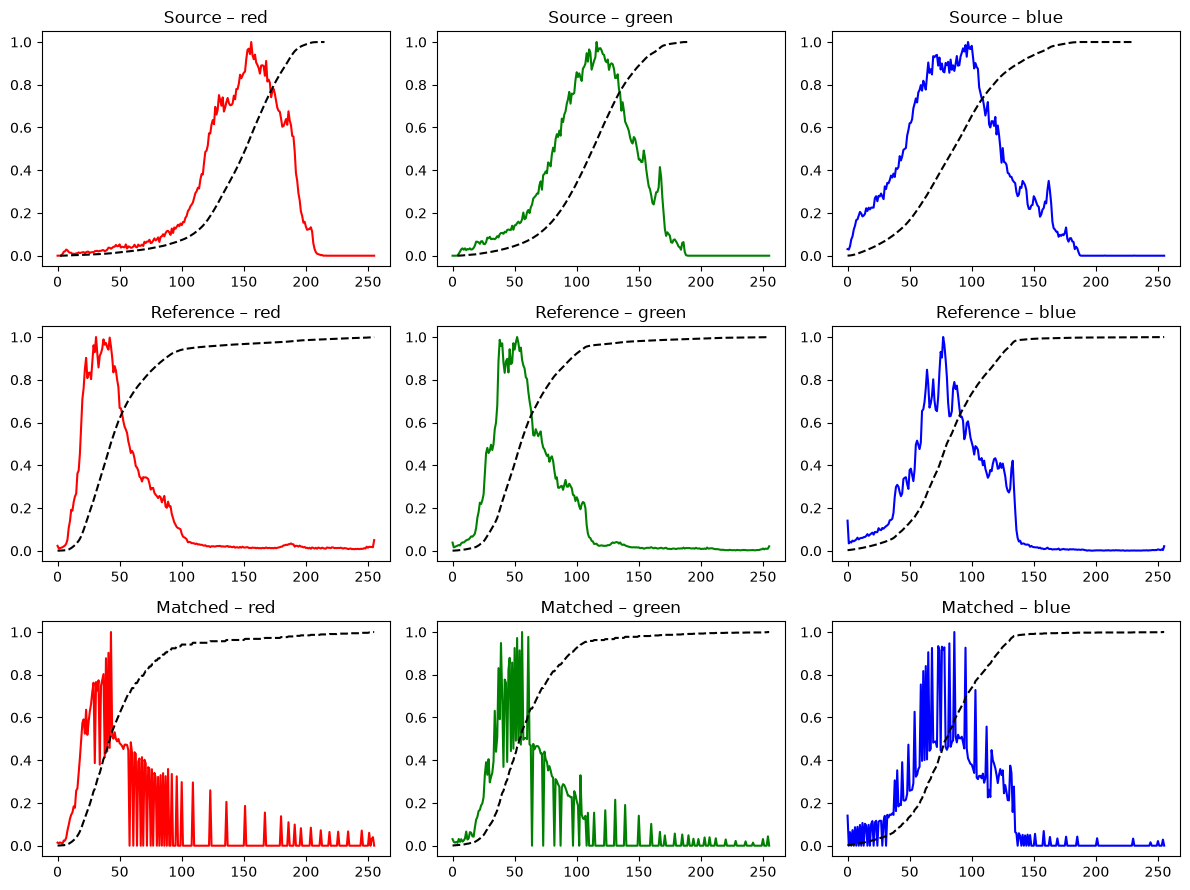

In [9]:
# Per-channel cumulative histograms: the matched CDF should follow the reference CDF
fig, axs = plt.subplots(3, 3, figsize=(12, 9))
for row, im, t in zip(axs, [image, reference, matched], ['Source', 'Reference', 'Matched']):
    for c, (ax, color) in enumerate(zip(row, ['red', 'green', 'blue'])):
        hist, bins = exposure.histogram(im[..., c], source_range='dtype')
        ax.plot(bins, hist / hist.max(), color=color)
        cdf, bins = exposure.cumulative_distribution(im[..., c])
        ax.plot(bins, cdf, 'k--')
        ax.set_title(f'{t} – {color}')
plt.tight_layout(); plt.show()